In [1]:
import os, duckdb, pandas as pd, matplotlib.pyplot as plt
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
con = duckdb.connect("data/processed/criteo.duckdb")
OUT = "module_1_criteo/outputs/"

In [2]:
con.execute("""
CREATE OR REPLACE TABLE conv AS
SELECT conversion_id, ANY_VALUE(uid) AS uid, MAX(conversion_timestamp) AS conv_ts
FROM raw WHERE conversion_id <> -1 GROUP BY conversion_id
""")
con.execute("""
CREATE OR REPLACE TABLE touches AS
SELECT c.conversion_id, r.campaign, r.timestamp, r.click, c.conv_ts
FROM conv c JOIN raw r ON r.uid = c.uid
WHERE r.timestamp <= c.conv_ts AND r.timestamp >= c.conv_ts - 30*86400
""")
con.sql("SELECT COUNT(*) AS touches, COUNT(DISTINCT conversion_id) AS conversions FROM touches").df()

,touches,conversions
0,2427167,435752


In [3]:
journeys = con.sql("""
SELECT conversion_id, COUNT(*) AS touches, COUNT(DISTINCT campaign) AS campaigns
FROM touches GROUP BY conversion_id
""").df()
print("Median touches per conversion:", journeys.touches.median())
print("Share of journeys with >1 campaign: {:.1%}".format((journeys.campaigns > 1).mean()))
journeys.campaigns.clip(upper=6).value_counts().sort_index()

Median touches per conversion: 3.0
Share of journeys with >1 campaign: 30.8%


campaigns
1    301609
2     94728
3     27233
4      8348
5      2616
6      1218
Name: count, dtype: int64

In [4]:
con.execute("""
CREATE OR REPLACE TABLE attribution AS
WITH r AS (
  SELECT *,
    ROW_NUMBER() OVER (PARTITION BY conversion_id ORDER BY timestamp, campaign)      AS rn_first,
    ROW_NUMBER() OVER (PARTITION BY conversion_id ORDER BY timestamp DESC, campaign) AS rn_last,
    COUNT(*)     OVER (PARTITION BY conversion_id)                                   AS n,
    POW(0.5, (conv_ts - timestamp) / (7*86400.0))                                    AS w
  FROM touches),
r2 AS (SELECT *, w / SUM(w) OVER (PARTITION BY conversion_id) AS w_norm FROM r)
SELECT campaign,
  SUM(CASE WHEN rn_first=1 THEN 1 ELSE 0 END) AS first_touch,
  SUM(CASE WHEN rn_last=1  THEN 1 ELSE 0 END) AS last_touch,
  SUM(1.0/n)                                  AS linear,
  SUM(w_norm)                                 AS time_decay
FROM r2 GROUP BY campaign
""")
attr = con.sql("SELECT * FROM attribution").df()
print("Total credit per model (should all equal total conversions):")
attr[["first_touch","last_touch","linear","time_decay"]].sum().round(0)

Total credit per model (should all equal total conversions):


first_touch    435752.0
last_touch     435752.0
linear         435752.0
time_decay     435752.0
dtype: float64

In [5]:
perf = pd.read_csv(OUT + "campaign_perf_stable.csv")[["campaign","spend","impressions"]]
m = perf.merge(attr, on="campaign", how="left").fillna(0)
models = ["first_touch","last_touch","linear","time_decay"]

for k in models:
    m[f"cpa_{k}"]  = m.spend / m[k].where(m[k] > 0)
    m[f"rank_{k}"] = m[f"cpa_{k}"].rank(method="min")

m["rank_shift_first_vs_last"] = (m.rank_first_touch - m.rank_last_touch)
m["abs_shift"] = m.rank_shift_first_vs_last.abs()
m.to_csv(OUT + "attribution_by_campaign.csv", index=False)
m.nlargest(10, "abs_shift")[["campaign","spend","last_touch","first_touch","linear",
                             "rank_last_touch","rank_first_touch","rank_shift_first_vs_last"]]

,campaign,spend,last_touch,first_touch,linear,rank_last_touch,rank_first_touch,rank_shift_first_vs_last
210,27888153,2.929535,102.0,211.0,150.968642,274.0,161.0,-113.0
275,19530182,35.319372,1354.0,2514.0,2029.753866,263.0,165.0,-98.0
325,5700346,3.260838,82.0,182.0,131.112903,308.0,217.0,-91.0
54,11843320,1.926509,80.0,138.0,105.732970,248.0,162.0,-86.0
188,28874676,8.346658,142.0,400.0,256.492603,326.0,245.0,-81.0
215,5044698,13.995507,619.0,1013.0,830.149833,230.0,157.0,-73.0
128,22723823,1.973304,85.0,136.0,112.674704,239.0,170.0,-69.0
59,27891651,5.512268,296.0,472.0,384.638305,192.0,126.0,-66.0
238,18898397,13.319632,757.0,637.0,705.833957,180.0,246.0,66.0
117,28729609,4.259968,363.0,286.0,309.475142,112.0,174.0,62.0


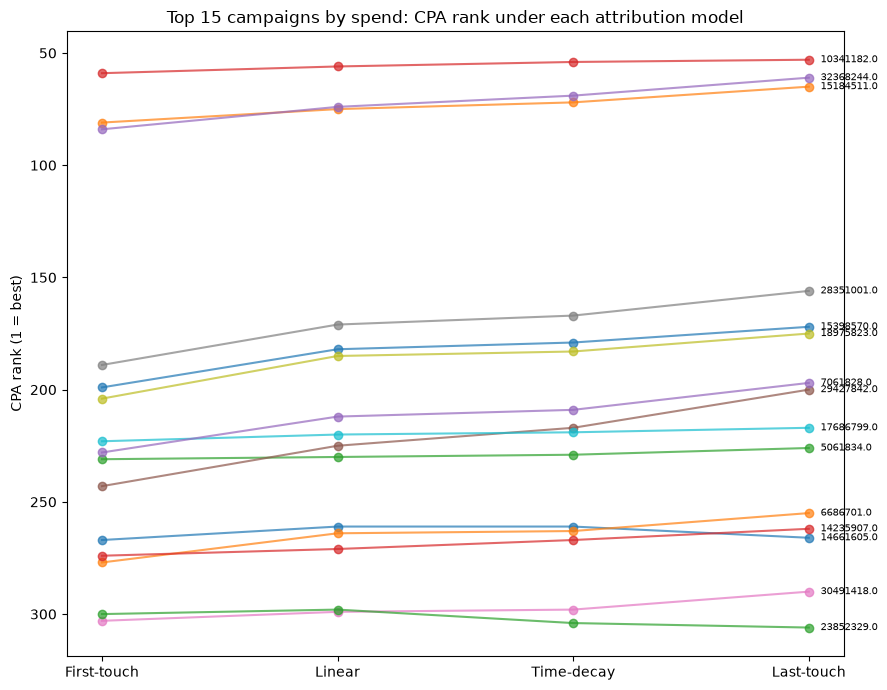

In [6]:
top = m.nlargest(15, "spend")
cols = ["rank_first_touch","rank_linear","rank_time_decay","rank_last_touch"]
labels = ["First-touch","Linear","Time-decay","Last-touch"]

fig, ax = plt.subplots(figsize=(9,7))
for _, row in top.iterrows():
    ax.plot(labels, row[cols].values, marker="o", alpha=0.7)
    ax.text(3.05, row["rank_last_touch"], str(row.campaign), fontsize=7, va="center")
ax.invert_yaxis()
ax.set_ylabel("CPA rank (1 = best)")
ax.set_title("Top 15 campaigns by spend: CPA rank under each attribution model")
plt.tight_layout(); plt.savefig(OUT + "attribution_slope.png", dpi=150); plt.show()

In [7]:
click_attr = con.sql("""
WITH r AS (
  SELECT *,
    ROW_NUMBER() OVER (PARTITION BY conversion_id ORDER BY timestamp)      AS rn_first,
    ROW_NUMBER() OVER (PARTITION BY conversion_id ORDER BY timestamp DESC) AS rn_last
  FROM touches WHERE click = 1)
SELECT campaign,
  SUM(CASE WHEN rn_first=1 THEN 1 ELSE 0 END) AS first_click,
  SUM(CASE WHEN rn_last=1  THEN 1 ELSE 0 END) AS last_click
FROM r GROUP BY campaign
""").df()
tot_conv = journeys.shape[0]
print(f"Conversions with ≥1 click in journey: {click_attr.last_click.sum():,.0f} "
      f"of {tot_conv:,} ({click_attr.last_click.sum()/tot_conv:.1%})")

Conversions with ≥1 click in journey: 435,704 of 435,752 (100.0%)


In [8]:
s = m.dropna(subset=["cpa_first_touch","cpa_last_touch"])
print(f"""
Campaigns compared: {len(s)}
Multi-campaign journeys: {(journeys.campaigns > 1).mean():.1%}
Campaigns whose CPA rank moves ≥10 places (first vs last): {(s.abs_shift >= 10).sum()}
Largest rank move: {s.abs_shift.max():.0f} places
Rank correlation first vs last touch: {s.rank_first_touch.corr(s.rank_last_touch, method='spearman'):.3f}
""")

ModuleNotFoundError: No module named 'scipy'